import

In [2]:
%matplotlib inline
import pandas as pd
from cd_library import draw_cd_diagram
from matplotlib import pyplot as plt
import numpy as np


caricamnto csv

In [26]:
df = pd.read_csv('csv_finale.csv')

manipolazione colonne e pulizia dati

In [27]:
df_perf = df.rename(columns={
    'algorithm': 'classifier_name',
    'dataset': 'dataset_name'
})
# 2. Definiamo le colonne su cui vogliamo calcolare media e deviazione standard
metrics = ['accuracy', 'f1_score', 'total_time_seconds', 'fit_time', 'predict_time']

# 3. Aggregazione: raggruppiamo per dataset e classificatore
# Usiamo 'agg' per calcolare sia mean che std in un colpo solo
df_grouped = df_perf.groupby(['dataset_name', 'classifier_name'])[metrics].agg(['mean', 'std']).reset_index()

# 4. Pulizia dei nomi delle colonne
# Dopo l'aggregazione le colonne sono multi-indice (es. ('accuracy', 'mean'))
# Le trasformiamo in nomi piatti come 'accuracy_mean'
df_grouped.columns = [
    f"{col[0]}_{col[1]}" if col[1] else col[0]
    for col in df_grouped.columns
]

# 5. Gestione dei metadati (train_size, series_length, num_classes)
# Poiché questi non cambiano tra i seed, prendiamo semplicemente il primo valore
metadata = df_perf.groupby(['dataset_name', 'classifier_name'])[['train_size', 'series_length', 'num_classes']].first().reset_index()

# 6. Uniamo i risultati aggregati con i metadati
df_final = pd.merge(df_grouped, metadata, on=['dataset_name', 'classifier_name'])

# Arrotondiamo per rendere il CSV più leggibile (opzionale)
df_final = df_final.round(4)

In [28]:
# Creiamo la tabella pivot per l'accuratezza media
pivot_accuracy = df_final.pivot(index='dataset_name', columns='classifier_name', values='accuracy_mean')

# Stampiamola a schermo
print(pivot_accuracy)


classifier_name      Arsenal    BOSS  HIVECOTEV2  InceptionTime  ResNet  \
dataset_name                                                              
Chinatown             0.9825  0.9067      0.9825         0.9835  0.9825   
Crop                  0.7378  0.6645      0.7459         0.7487  0.7129   
DiatomSizeReduction   0.9739  0.9281      0.9510         0.9237  0.9684   
ElectricDevices       0.7280  0.6732         NaN         0.7033  0.7382   
FordB                 0.8111  0.8160      0.8198         0.8568  0.8029   
Fungi                 1.0000  0.9946         NaN         1.0000  0.8136   
HandOutlines          0.9396  0.9189      0.9405         0.9495  0.7928   
HouseTwenty           0.9664  0.9748      0.9748         0.9720  0.9776   
InsectEPGSmallTrain   0.9813  0.9277      0.9719         0.9424  0.7992   
ItalyPowerDemand      0.9699  0.9310      0.9699         0.9653  0.9602   
Rock                  0.9000  0.7600      0.9600         0.7800  0.4467   
SmoothSubspace        0.9

In [29]:
pivot_accuracy.to_csv('tabella_accuratezza_tesi.csv')

critical difference diagram per accuracy

In [31]:
# 1. Usa il DataFrame originale (quello con tutti i seed)
# Assicurati che abbia le colonne 'classifier_name', 'dataset_name' e 'accuracy'
df_for_plot = df_perf[['dataset_name', 'classifier_name', 'accuracy']].copy()

# 2. IMPORTANTE: HIVE-COTE ha solo 1 seed, gli altri 3.
# Il test di Wilcoxon richiede che il numero di osservazioni sia identico.
# Dobbiamo calcolare la media per dataset/algoritmo prima di passarlo al grafico
# in modo che ogni algoritmo abbia lo stesso numero di campioni (uno per dataset).
df_input_plot = df_for_plot.groupby(['dataset_name', 'classifier_name'])['accuracy'].mean().reset_index()

In [7]:
draw_cd_diagram(df_perf=df_input_plot, title='Accuracy Comparison', labels=True)

['Arsenal' 'BOSS' 'HIVECOTEV2' 'InceptionTime' 'ResNet' 'Rocket' 'WEASEL']
Arsenal          1.0
BOSS             0.0
InceptionTime    3.0
ResNet           2.0
Rocket           2.0
WEASEL           1.0
dtype: float64
BOSS             4.750000
WEASEL           4.375000
ResNet           3.958333
InceptionTime    2.791667
Arsenal          2.583333
Rocket           2.541667
dtype: float64
('BOSS', 'InceptionTime', np.float64(0.00244140625), True)
('Arsenal', 'BOSS', np.float64(0.00341796875), True)
('BOSS', 'Rocket', np.float64(0.0048828125), False)
('Arsenal', 'WEASEL', np.float64(0.005859375), False)
('Rocket', 'WEASEL', np.float64(0.005859375), False)
('Arsenal', 'ResNet', np.float64(0.083984375), False)
('ResNet', 'Rocket', np.float64(0.09228515625), False)
('InceptionTime', 'WEASEL', np.float64(0.119140625), False)
('InceptionTime', 'ResNet', np.float64(0.12939453125), False)
('BOSS', 'WEASEL', np.float64(0.26611328125), False)
('InceptionTime', 'Rocket', np.float64(0.400390625), False

barplot per i tempi

In [33]:
# --- PREPARAZIONE DATI (comune a entrambi) ---
df_by_dataset = df_perf.groupby(['dataset_name', 'classifier_name'])[['fit_time', 'predict_time']].mean().reset_index()
df_agg = df_by_dataset.groupby('classifier_name')[['fit_time', 'predict_time']].sum().reset_index()
df_agg['total'] = df_agg['fit_time'] + df_agg['predict_time']
df_agg = df_agg.sort_values('total', ascending=False)

def plot_and_save(log_scale=False, filename='grafico.pdf'):
    plt.figure(figsize=(10, 7))

    # Disegno le barre
    plt.bar(df_agg['classifier_name'], df_agg['fit_time'], label='Fit Time (Training)', color='#4c72b0')
    plt.bar(df_agg['classifier_name'], df_agg['predict_time'], bottom=df_agg['fit_time'],
            label='Predict Time (Inference)', color='#dd8452')

    # Configurazione scala e scritte
    if log_scale:
        plt.yscale('log')
        plt.ylabel('Tempo Totale (secondi) - Scala Logaritmica')
        plt.title('Efficienza Computazionale (Log Scale)')
        plt.grid(axis='y', linestyle='-', alpha=0.3, which="major")
    else:
        plt.ylabel('Tempo Totale (secondi)')
        plt.title('Efficienza Computazionale (Linear Scale)')
        plt.grid(axis='y', linestyle='-', alpha=0.3)

    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Salvataggio
    plt.savefig(filename, bbox_inches='tight')
    print(f"File salvato: {filename}")
    plt.close() # Fondamentale per non sovrapporre i grafici in memoria

# 1. Salva il grafico Lineare
plot_and_save(log_scale=False, filename='confronto_tempi_lineare.pdf')

# 2. Salva il grafico Logaritmico
plot_and_save(log_scale=True, filename='confronto_tempi_logaritmico.pdf')

File salvato: confronto_tempi_lineare.pdf
File salvato: confronto_tempi_logaritmico.pdf


In [3]:
import os
# Carica il file grezzo
path = "../ucr/Fungi/Fungi_TRAIN.tsv"

if os.path.exists(path):
    df_TRAIN = pd.read_csv(path, sep='\t', header=None)
    y = df_TRAIN.iloc[:, 0].values
    X_raw = df_TRAIN.iloc[:, 1:].values
    print(f"Dataset caricato correttamente!")
    print(f"Dimensioni: {X_raw.shape[0]} serie, lunghezza {X_raw.shape[1]}")
else:
    print(f"Errore: il file non è stato trovato al percorso {os.path.abspath(path)}")

Dataset caricato correttamente!
Dimensioni: 18 serie, lunghezza 201


In [4]:
print(f"Valori nulli nel dataset grezzo: {df_TRAIN.isnull().sum().sum()}")

Valori nulli nel dataset grezzo: 0


In [5]:
path = "../ucr/Fungi/Fungi_TEST.tsv"

if os.path.exists(path):
    df_TEST = pd.read_csv(path, sep='\t', header=None)
    y = df_TEST.iloc[:, 0].values
    X_raw = df_TEST.iloc[:, 1:].values
    print(f"Dataset caricato correttamente!")
    print(f"Dimensioni: {X_raw.shape[0]} serie, lunghezza {X_raw.shape[1]}")
else:
    print(f"Errore: il file non è stato trovato al percorso {os.path.abspath(path)}")

Dataset caricato correttamente!
Dimensioni: 186 serie, lunghezza 201


In [6]:
print(f"Valori nulli nel dataset grezzo: {df_TEST.isnull().sum().sum()}")

Valori nulli nel dataset grezzo: 0


In [8]:
def test_your_normalization(X_raw, name="Dataset"):
    X_norm = np.copy(X_raw).astype(float)
    count_flat = 0
    count_nan_after = 0

    for i in range(len(X_norm)):
        # Calcoliamo media e std come faceva il tuo script
        m = np.mean(X_norm[i])
        s = np.std(X_norm[i])

        if s == 0:
            count_flat += 1
            X_norm[i] = X_norm[i] - m  # Diventa una serie di soli ZERI
        else:
            X_norm[i] = (X_norm[i] - m) / s

        # Controllo se dopo l'operazione sono apparsi NaN
        if np.isnan(X_norm[i]).any():
            count_nan_after += 1

    print(f"--- Risultati Normalizzazione su {name} ---")
    print(f"Serie totali: {len(X_norm)}")
    print(f"Serie piatte (s=0) trovate: {count_flat}")
    print(f"Serie che contengono NaN dopo norm: {count_nan_after}")
    print(f"Valore MAX assoluto dopo norm: {np.max(np.abs(X_norm))}")
    print("-" * 40)
    return X_norm

# Applichiamo ai tuoi dati caricati
X_train_norm = test_your_normalization(df_TRAIN, "TRAIN") # Usa il nome della variabile che hai usato per il training
X_test_norm = test_your_normalization(df_TEST, "TEST")

--- Risultati Normalizzazione su TRAIN ---
Serie totali: 18
Serie piatte (s=0) trovate: 0
Serie che contengono NaN dopo norm: 0
Valore MAX assoluto dopo norm: 5.680697874278669
----------------------------------------
--- Risultati Normalizzazione su TEST ---
Serie totali: 186
Serie piatte (s=0) trovate: 0
Serie che contengono NaN dopo norm: 0
Valore MAX assoluto dopo norm: 5.951756839439322
----------------------------------------


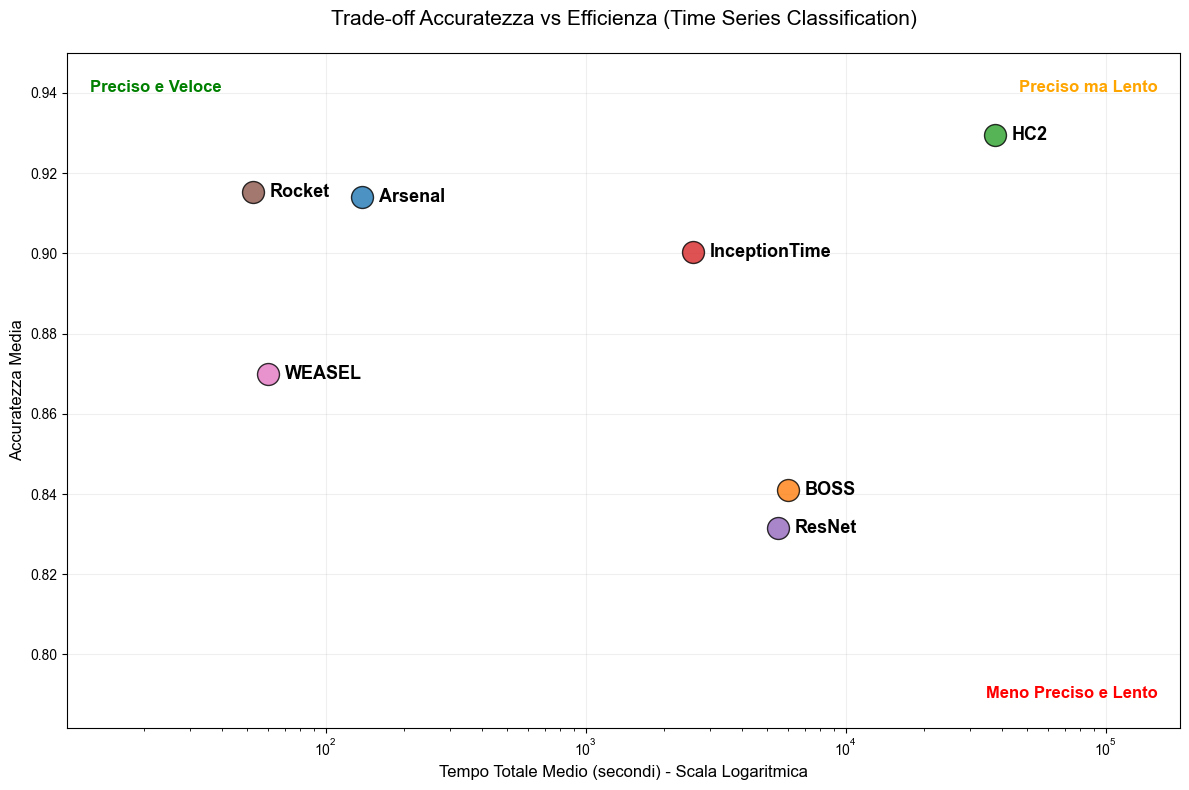

In [52]:
# 1. Preparazione dati
df_by_algo = df_perf.groupby(['dataset_name', 'classifier_name'])[['accuracy', 'total_time_seconds']].mean().reset_index()
df_final_avg = df_by_algo.groupby('classifier_name')[['accuracy', 'total_time_seconds']].mean().reset_index()

# Ridenominazione
name_mapping = {'HIVECOTEV2': 'HC2', 'InceptionTime': 'InceptionTime', 'Rocket': 'Rocket'}
df_final_avg['classifier_name'] = df_final_avg['classifier_name'].replace(name_mapping)

# 2. Creazione dello scatter plot
plt.figure(figsize=(12, 8))

for i, row in df_final_avg.iterrows():
    plt.scatter(row['total_time_seconds'], row['accuracy'], s=250, alpha=0.8, edgecolors='k', zorder=3)

    plt.annotate(row['classifier_name'],
                 xy=(row['total_time_seconds'], row['accuracy']),
                 xytext=(12, 0),
                 textcoords="offset points",
                 fontsize=13,
                 fontweight='bold',
                 va='center')

# 3. Scala Logaritmica per l'asse X
plt.xscale('log')

# 4. LIMITE ASSE Y (La tua modifica)
# Impostiamo l'accuratezza da un valore minimo (es. 0.6 o 0.0) fino a 1.05
# Il 1.05 serve a lasciare un po' di "cielo" sopra il 100% per le scritte
plt.ylim(df_final_avg['accuracy'].min() - 0.05, 0.95)

# 5. Annotazioni negli angoli (Interne come richiesto)
ax = plt.gca()
ax.text(0.02, 0.96, 'Preciso e Veloce', transform=ax.transAxes, fontsize=12, color='green', fontweight='bold', va='top')
ax.text(0.98, 0.96, 'Preciso ma Lento', transform=ax.transAxes, fontsize=12, color='orange', fontweight='bold', va='top', ha='right')
ax.text(0.98, 0.04, 'Meno Preciso e Lento', transform=ax.transAxes, fontsize=12, color='red', fontweight='bold', va='bottom', ha='right')

# 6. Abbellimenti
plt.xlabel('Tempo Totale Medio (secondi) - Scala Logaritmica', fontsize=12)
plt.ylabel('Accuratezza Media', fontsize=12)
plt.title('Trade-off Accuratezza vs Efficienza (Time Series Classification)', fontsize=15, pad=20)

# Margini per l'asse X (tempo)
plt.margins(x=0.25)

plt.grid(True, which="major", ls="-", alpha=0.2, zorder=0)

# 7. Salvataggio
plt.tight_layout()
plt.savefig('scatter_accuracy_vs_time.pdf', bbox_inches='tight')
plt.show()

In [37]:
print(df_final_avg)

  classifier_name  accuracy  total_time_seconds
0         Arsenal  0.914018          138.322106
1            BOSS  0.840925         6009.007975
2             HC2  0.929623        37384.567396
3   InceptionTime  0.900263         2584.703810
4          ResNet  0.831611         5506.628636
5          Rocket  0.915306           52.540286
6          WEASEL  0.869909           60.322647
